# SpectraRFˣ -- real closed-set evidence figures

Every figure below is generated directly from the platform's own real, persisted
evidence -- the exact same aggregation `ScientificResultsRepository.
get_evidence_dashboard_summary()` serves live to the Evidence Dashboard tab
(`GET /api/ble-scientific-results/evidence-dashboard`). No synthetic values, no
recomputation: this notebook only calls the plotting functions in
`generate_evidence_figures.py` and renders their real output.

Re-run this notebook any time the underlying real results change -- it always
reads current state, never a frozen snapshot.


In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().resolve().parents[1] if Path.cwd().name == "ble" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT / "docs" / "ble"))

from generate_evidence_figures import (
    load_repository, fig_rq1_domains, fig_rq2_branches, fig_confusion,
    fig_per_unit_metrics, fig_risk_coverage, fig_seed_variability,
    fig_computational_cost, fig_per_unit_auxiliary_rq1, sync_consolidated_figures,
)

repo = load_repository()
summary = repo.get_evidence_dashboard_summary()


## RQ1 -- closed-set acquisition dependence

`delta_dependence = BA_window - BA_capture`, the manuscript's Eq. 12 contrast. `BA_window` is the intentionally capture-dependent diagnostic (train/validation windows share a session); `BA_capture` is the confirmatory, capture-disjoint result. The gap between them is real, on-hardware evidence of the acquisition-dependence optimism the manuscript's methodology section argues for.

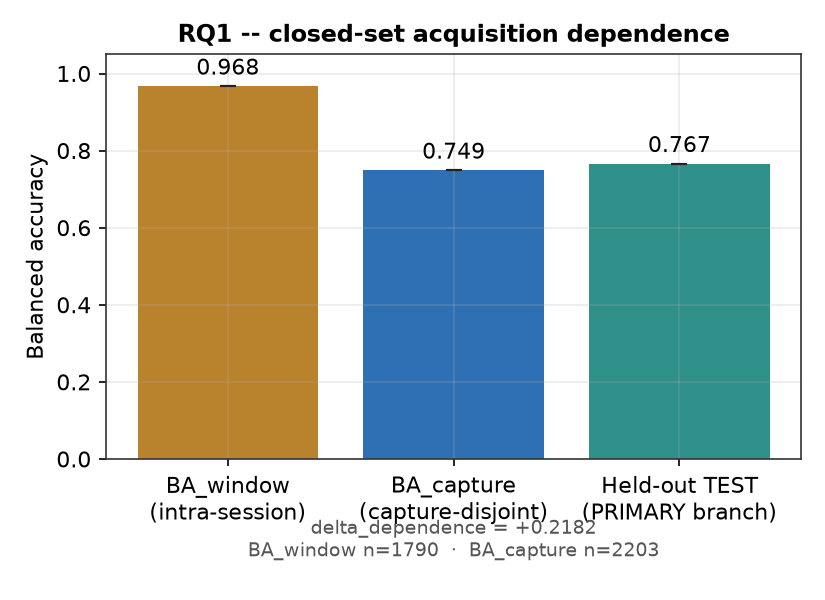

In [1]:
fig_rq1_domains(summary)

## RQ2 -- signal-representation comparison

All four branches (`coarse_morphology`, `engineered_rf`, `raw_iq`, `stft`) trained on the same admitted acquisition groups and decision windows. PRIMARY branch selected on VALIDATION only.

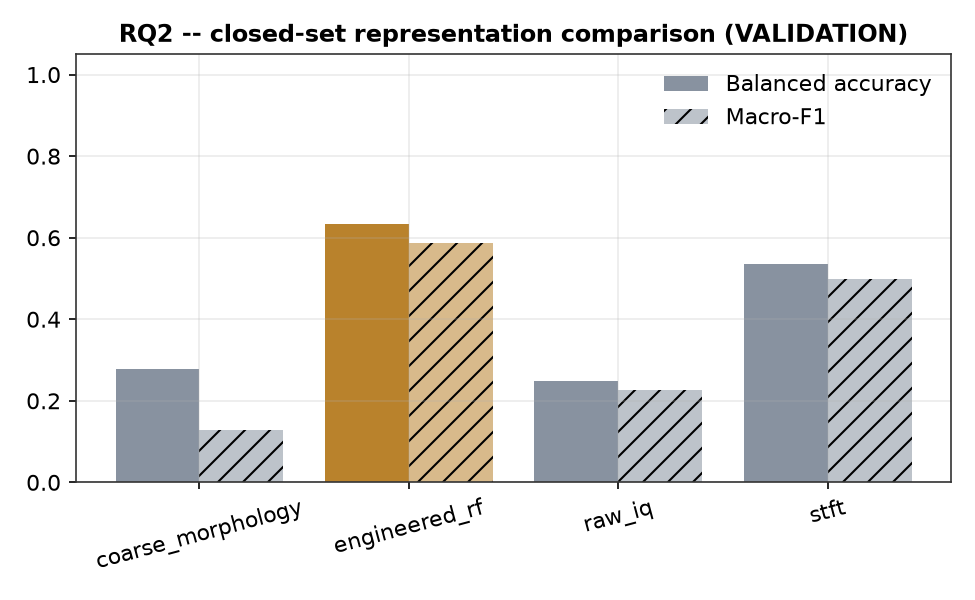

In [1]:
fig_rq2_branches(summary)

## Confusion matrices

Capture-disjoint VALIDATION (left) vs. held-out TEST (right) for the PRIMARY branch -- CC2650-UNIT-01 is perfectly separated (recall 1.0) in both.

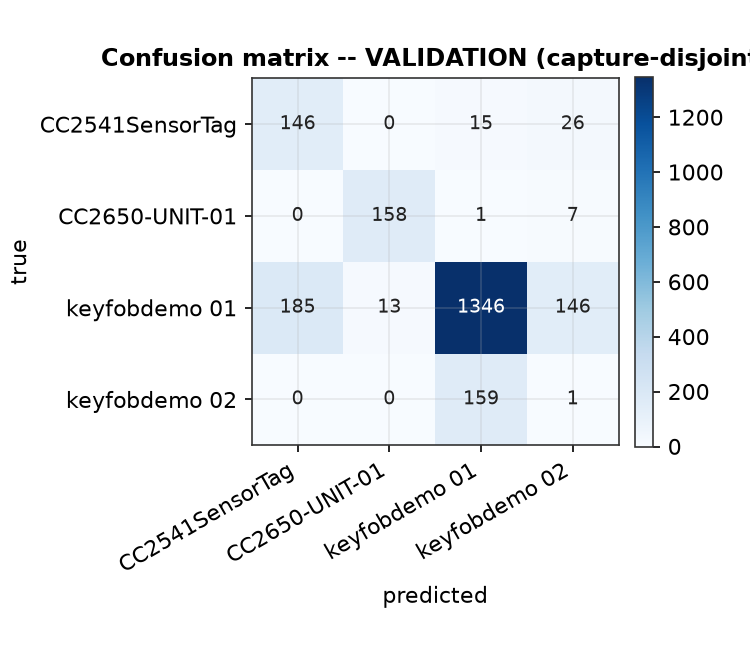

In [1]:
fig_confusion_validation = fig_confusion(
    summary['closed_set']['rq1']['confusion_matrix_capture'],
    'Confusion matrix -- VALIDATION (capture-disjoint)', 'evidence_confusion_validation.png')

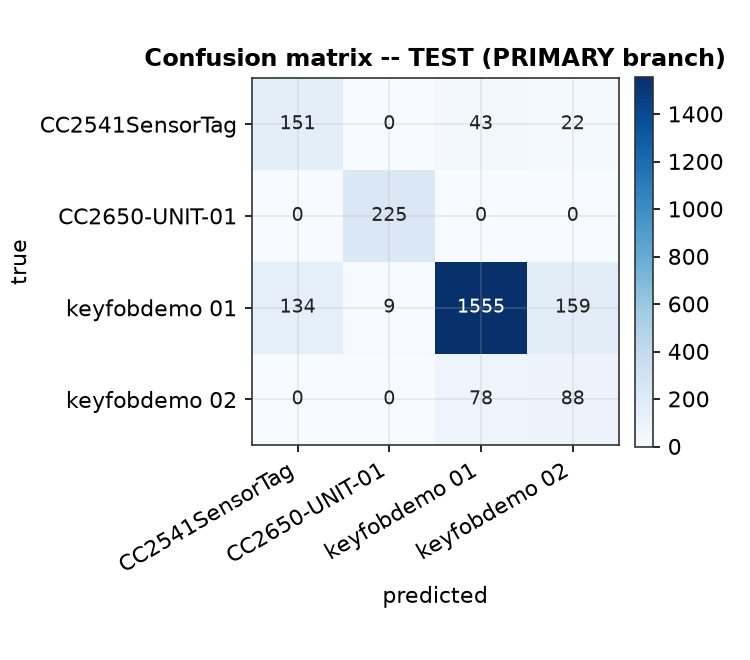

In [1]:
fig_confusion_test = fig_confusion(
    summary['closed_set']['primary_test']['confusion_matrix'],
    'Confusion matrix -- TEST (PRIMARY branch)', 'evidence_confusion_test.png')

## Per-unit precision / recall / F1 (TEST)

Reported per unit, not only as an aggregate, because the closed-set TEST split is naturally imbalanced (1,857 KEYFOB01 examples vs. 166 KEYFOB02) -- balanced accuracy and macro-F1 (used throughout this study) are exactly the metrics that stay informative under this imbalance, unlike raw accuracy.

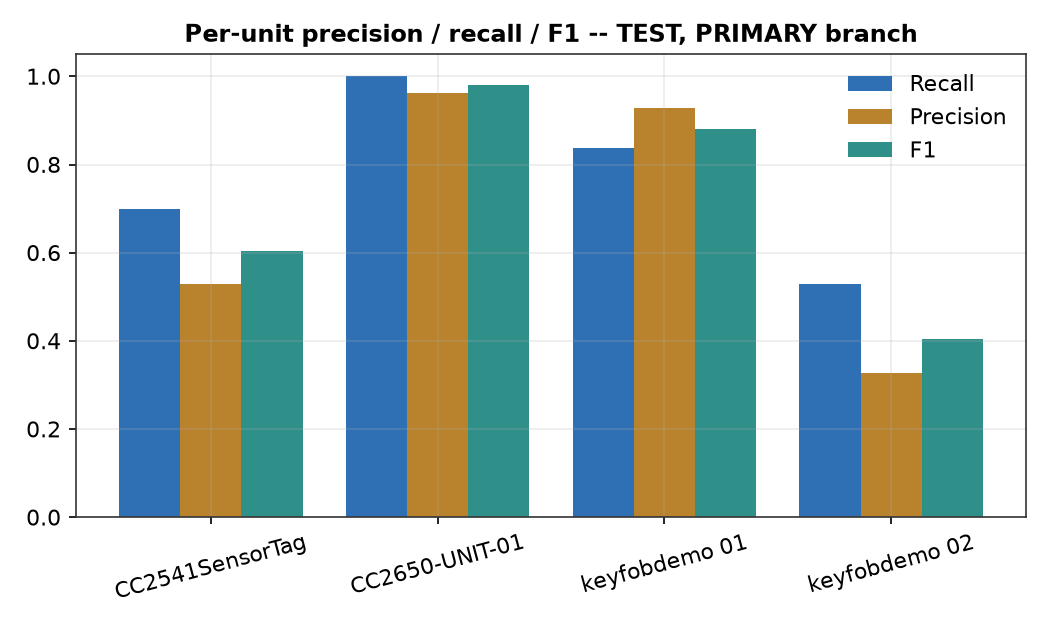

In [1]:
fig_per_unit_metrics(summary)

## Risk-coverage curve (TEST, PRIMARY branch)

The selective-prediction curve (El-Yaniv & Wiener, 2010) the manuscript's abstention mechanism is built on -- one point per achievable confidence threshold, real predictions from the real held-out TEST split.

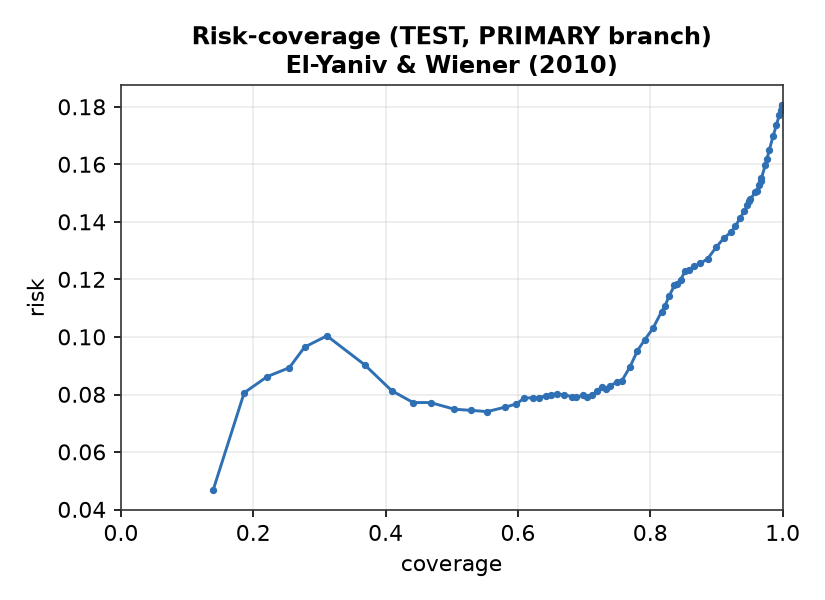

In [1]:
fig_risk_coverage(summary)

## Seed variability (PRIMARY branch)

The PRIMARY branch re-trained under the platform's two other frozen seeds (`137`, `2024`), VALIDATION-only -- a real reproducibility check, not a claim about TEST stability.

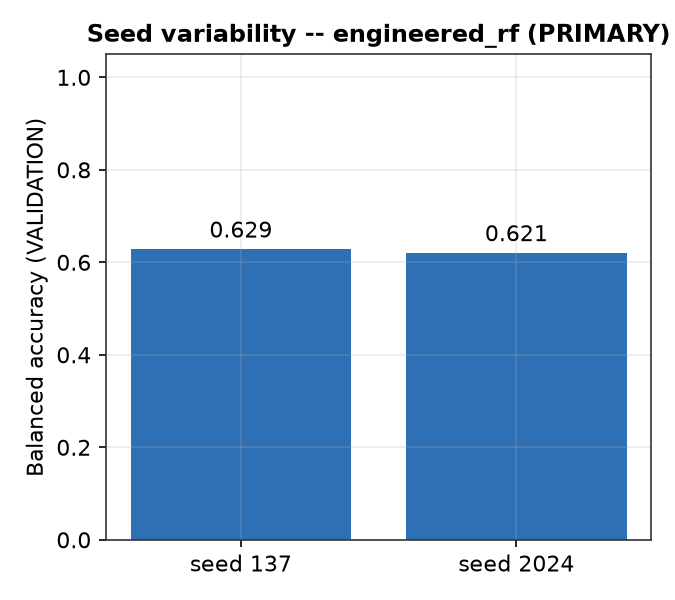

In [1]:
fig_seed_variability(summary)

## Computational cost by RQ2 branch

Real inference latency and serialized model size per branch, supporting the manuscript's stated computational-cost comparison.

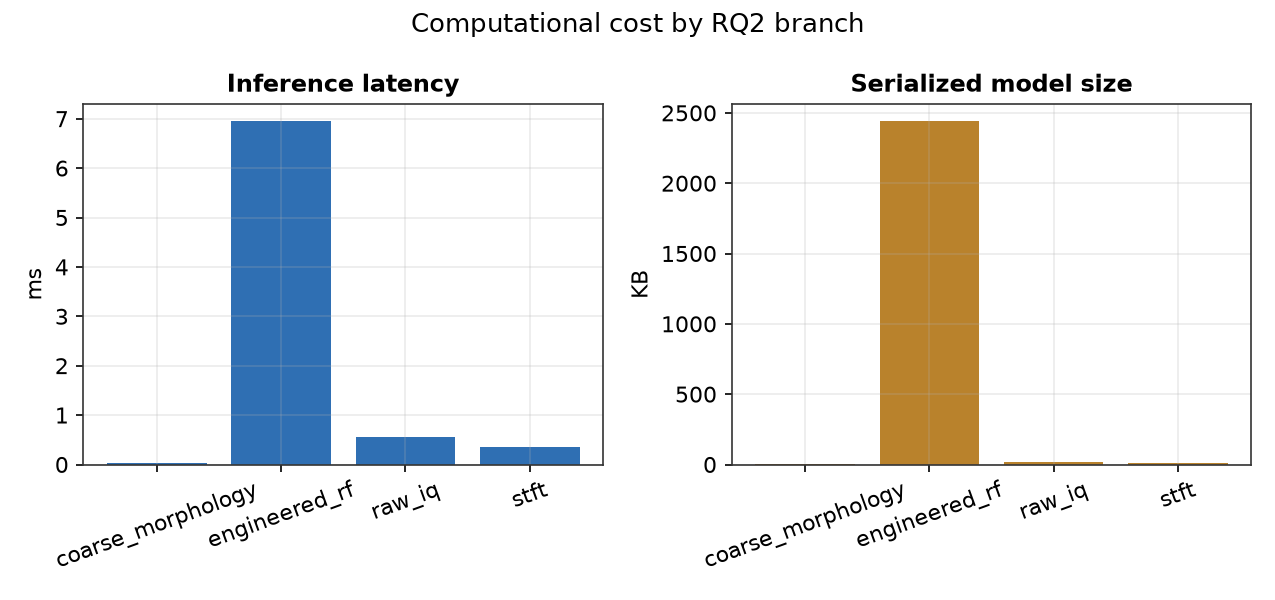

In [1]:
fig_computational_cost(summary)

## Per-unit auxiliary TARGET_VS_BACKGROUND runs

The 4 individual per-unit binary detectors, kept as an auxiliary analysis, never substituted for the closed-set result above -- their own real `delta_dependence` is consistently smaller than the closed-set effect, because target-vs-background is an easier task with more redundant evidence per window.

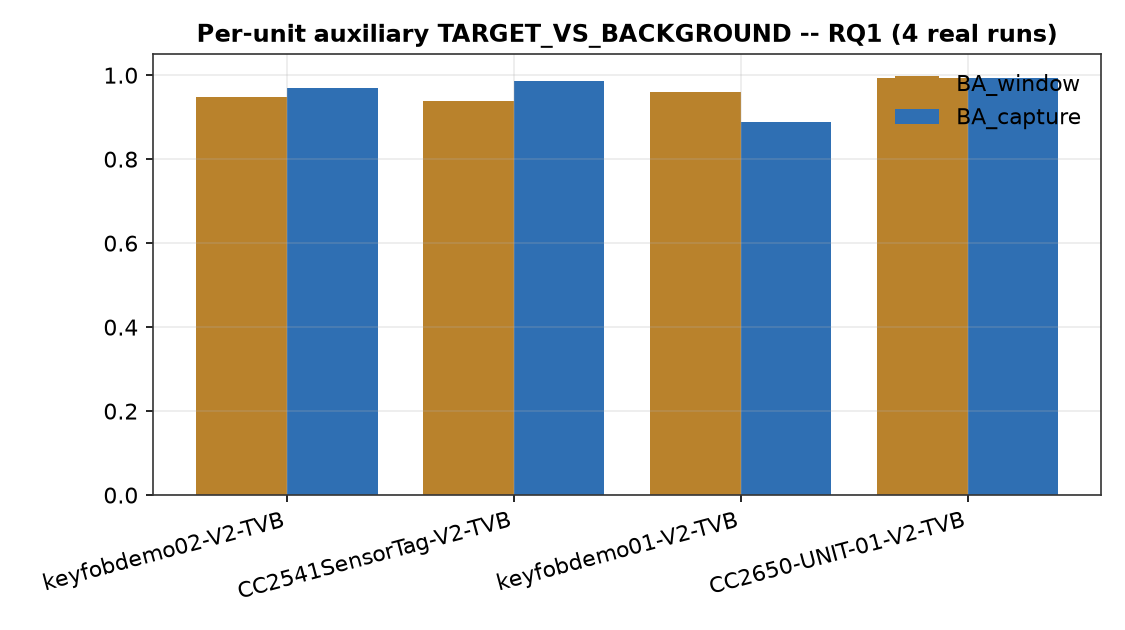

In [1]:
fig_per_unit_auxiliary_rq1(summary)

## Campaign timeline (real, current status)

Every study phase -- qualification through protected FUTURE and confirmatory analysis -- colored by its real `execution_state`. Rendered once by the paper-export pipeline (`figures/paper_figures.py`) and copied here, not re-plotted, so this view can never drift from the manuscript's own timeline figure.

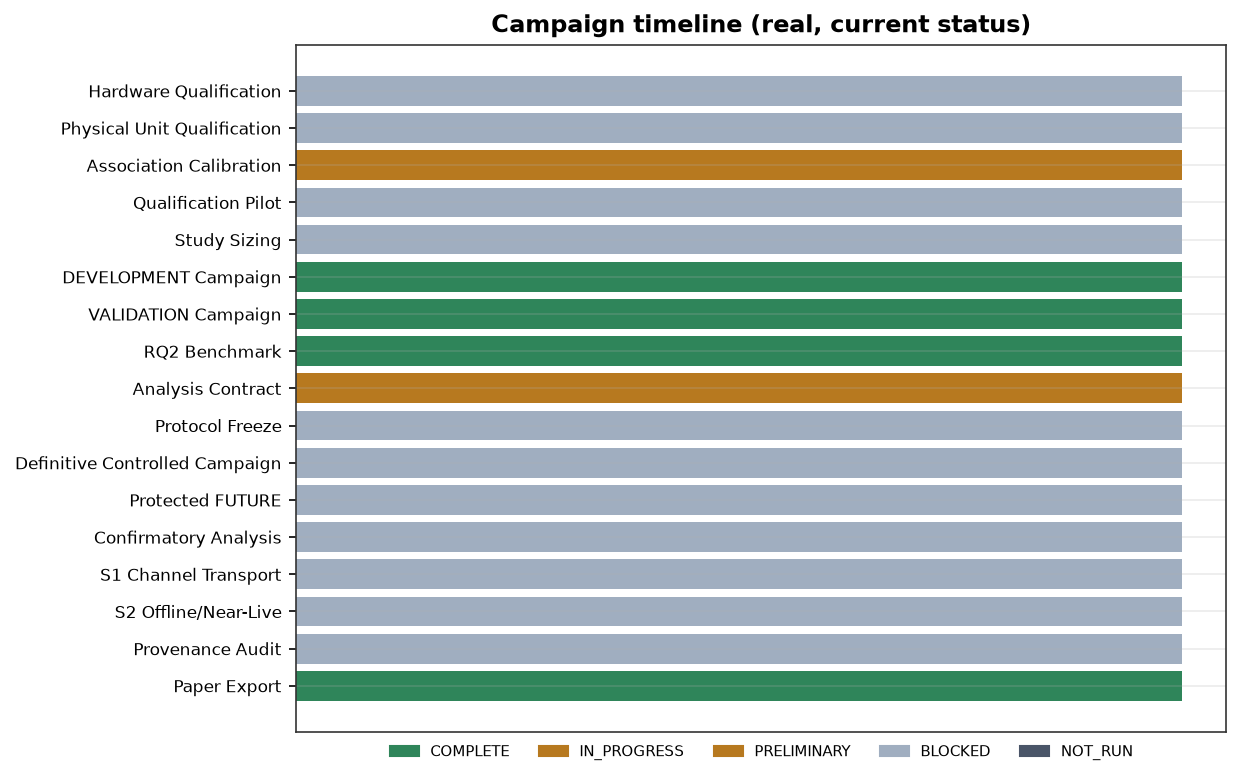

In [1]:
sync_consolidated_figures(repo)

## Confusion matrix, normalized by true class (TEST, PRIMARY branch)

Same real counts as the raw confusion matrix above, row-normalized to a per-class percentage with `n` kept as secondary per-cell information -- the canonical normalized view for the manuscript, from the same paper-export renderer as the timeline above.

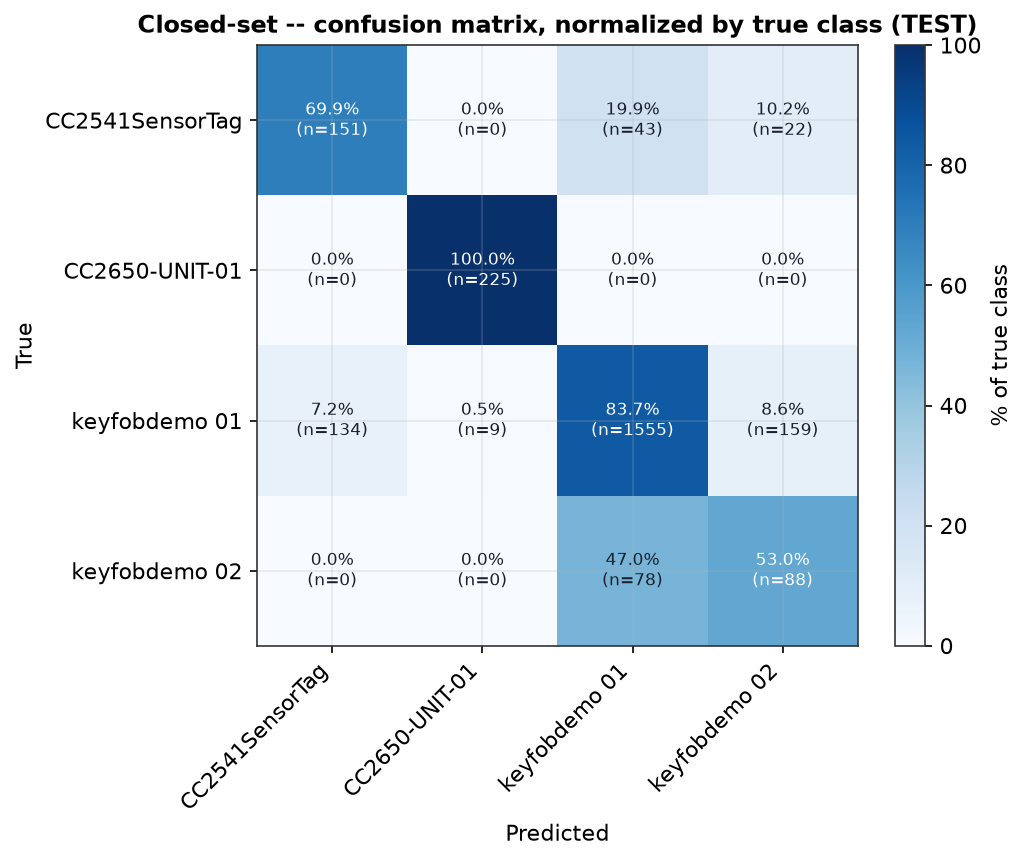

In [1]:
# already rendered by sync_consolidated_figures(repo) above

## Forensic evidence lineage

Source I/Q -> burst -> PDU -> admitted example -> dataset -> split -> preprocessing -> model -> window decision, traced with real IDs/hashes from the closed-set PRIMARY branch -- not a dashboard screenshot, a diagram built from the same real artifacts as every other figure in this notebook.

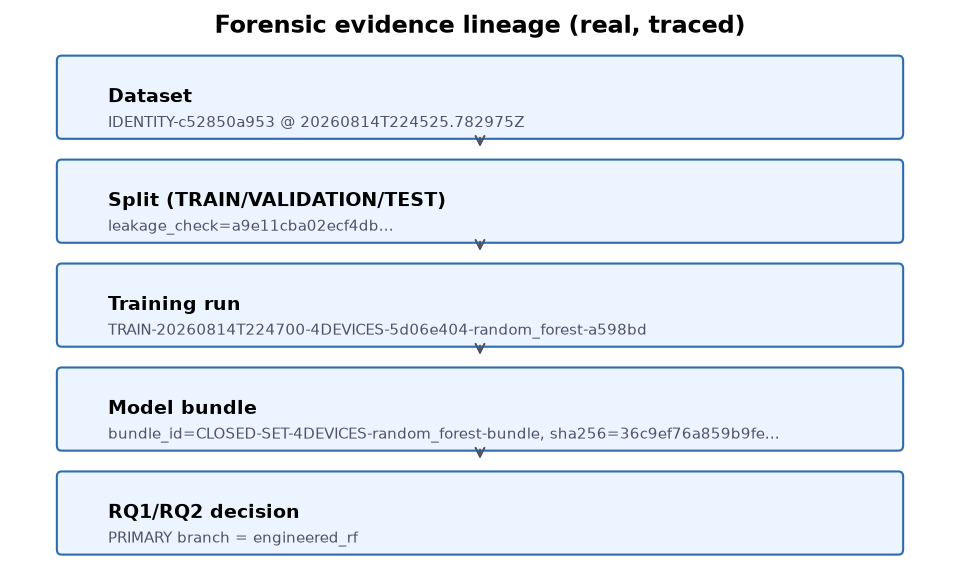

In [1]:
# already rendered by sync_consolidated_figures(repo) above